In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout, BatchNormalization, Reshape
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from scipy.interpolate import interp1d

In [25]:
# Define the global curve length variable
CURVE_POINTS = 100 

def process_grouped_data(df, curve_length=CURVE_POINTS):
    X_inputs = []
    yt_curves = []
    yp_curves = []
    ys_scalars = []
    
    # Input features (Geometry)
    input_cols = ['Length', 'Diameter', 'Slot_Length', 'Slot_Width', 'Throat_Diameter', 'Exit_Diameter'] 
    
    # EXACT names of the 5 scalar outputs
    scalar_cols = ['ISP (s)', 'Total Impulse (Ns)', 'Burn Time (s)', 'Max Thrust (N)', 'Peak Pressure (MPa)'] 
    
    # Group by 'ID'
    grouped = df.groupby('ID')
    
    for name, group in grouped:
        X_inputs.append(group[input_cols].iloc[0].values)
        ys_scalars.append(group[scalar_cols].iloc[0].values)
        
        time = group['Time (s)'].values
        thrust = group['Thrust (N)'].values
        pressure = group['Pressure (MPa)'].values
        
        if time.max() > time.min():
            time_normalized = (time - time.min()) / (time.max() - time.min())
        else:
            time_normalized = np.zeros_like(time)
            
        target_time = np.linspace(0, 1, curve_length)
        
        f_thrust = interp1d(time_normalized, thrust, kind='linear')
        f_pressure = interp1d(time_normalized, pressure, kind='linear')
        
        yt_curves.append(f_thrust(target_time))
        yp_curves.append(f_pressure(target_time))
        
    return np.array(X_inputs), np.array(yt_curves), np.array(yp_curves), np.array(ys_scalars)

# ==========================================
# FILE LOADING AND CLEANING SECTION
# ==========================================
file_path = '/kaggle/input/datasets/abdelrahmanmr/x-grain/Rocket_Results_Full_Data.csv' 

print(f"Loading data from {file_path}...")
df = pd.read_csv(file_path, low_memory=False)

numeric_columns = ['ID', 'Length', 'Diameter', 'Slot_Length', 'Slot_Width', 'Throat_Diameter', 'Exit_Diameter',
                   'Time (s)', 'Thrust (N)', 'Pressure (MPa)', 
                   'ISP (s)', 'Total Impulse (Ns)', 'Burn Time (s)', 'Max Thrust (N)', 'Peak Pressure (MPa)']

# Filter dataset to only include specified columns
df = df[numeric_columns]

# --- NEW DATA CLEANING STEP ---
print("Cleaning data: Replacing text errors (like 'Error') with NaN and dropping them...")
# Force convert all columns (except ID) to numeric. Non-numeric text becomes NaN.
cols_to_clean = [col for col in numeric_columns if col != 'ID']
for col in cols_to_clean:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Now drop any row that has NaN (this drops the 'Error' rows)
df = df.dropna()
# ------------------------------

print("Processing grouped data...")
X, yt, yp, ys = process_grouped_data(df, curve_length=CURVE_POINTS)
print("Data loaded and processed successfully!")

Loading data from /kaggle/input/datasets/abdelrahmanmr/x-grain/Rocket_Results_Full_Data.csv...
Cleaning data: Replacing text errors (like 'Error') with NaN and dropping them...
Processing grouped data...
Data loaded and processed successfully!


In [26]:
X_train, X_test, yt_train, yt_test, yp_train, yp_test, ys_train, ys_test = train_test_split(
    X, yt, yp, ys, test_size=0.15, random_state=42
)

scaler_X = RobustScaler()
X_tr_s = scaler_X.fit_transform(X_train)
X_te_s = scaler_X.transform(X_test)

scaler_ys = StandardScaler()
ys_tr_s = scaler_ys.fit_transform(ys_train)
ys_te_s = scaler_ys.transform(ys_test) 

max_thrust_global = np.max(yt_train)
max_pressure_global = np.max(yp_train)

yt_tr_s = yt_train / max_thrust_global
yp_tr_s = yp_train / max_pressure_global

yt_te_s = yt_test / max_thrust_global
yp_te_s = yp_test / max_pressure_global

print(f"Shapes -> X_train: {X_tr_s.shape}, yt_train: {yt_tr_s.shape}, yp_train: {yp_tr_s.shape}, ys_train: {ys_tr_s.shape}")

Shapes -> X_train: (2874, 6), yt_train: (2874, 100), yp_train: (2874, 100), ys_train: (2874, 5)


In [27]:
from tensorflow.keras.regularizers import l2

def shape_matching_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    mse = tf.reduce_mean(tf.square(y_true - y_pred), axis=-1)
    diff_true = y_true[:, 1:] - y_true[:, :-1]
    diff_pred = y_pred[:, 1:] - y_pred[:, :-1]
    shape_penalty = tf.reduce_mean(tf.square(diff_true - diff_pred), axis=-1)
    return mse + 0.5 * shape_penalty

def build_model(input_dim=6, curve_len=CURVE_POINTS, num_scalars=5):
    inputs = Input(shape=(input_dim,), name="geometry_inputs")
    
    # --- Shared Feature Extractor ---
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(inputs)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x) 
    
    x_seq = tf.keras.layers.RepeatVector(curve_len)(x) 
    
    # --- Branch 1: Thrust ---
    bt = LSTM(128, return_sequences=True)(x_seq)
    bt = LSTM(64, return_sequences=True)(bt)
    bt = Reshape((curve_len, 64))(bt)
    thrust_out = tf.keras.layers.TimeDistributed(Dense(1))(bt)
    thrust_out = Reshape((curve_len,), name="thrust_output")(thrust_out)
    
    # --- Branch 2: Pressure ---
    bp = LSTM(128, return_sequences=True)(x_seq)
    bp = LSTM(64, return_sequences=True)(bp)
    bp = Reshape((curve_len, 64))(bp)
    pressure_out = tf.keras.layers.TimeDistributed(Dense(1))(bp)
    pressure_out = Reshape((curve_len,), name="pressure_output")(pressure_out)
    
    # --- Branch 3: Scalars ---
    bs = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)
    bs = Dropout(0.25)(bs)
    bs = Dense(64, activation='relu', kernel_regularizer=l2(0.001))(bs)
    scalars_out = Dense(num_scalars, name="scalars_output")(bs)
    
    model = Model(inputs=inputs, outputs=[thrust_out, pressure_out, scalars_out])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss={
            "thrust_output": shape_matching_loss,
            "pressure_output": shape_matching_loss,
            "scalars_output": tf.keras.losses.Huber() 
        },
        loss_weights={
            "thrust_output": 1.0, 
            "pressure_output": 1.0, 
            "scalars_output": 1.0 # إعادتها للوزن المتوازن
        }
    )
    return model

model = build_model()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ geometry_inputs     │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │        896 │ geometry_inputs[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_6[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 256)       │     33,024 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_7[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_1     │ (None, 100, 256)  │          0 │ dropout_2[0][0]   │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 100, 128)  │    197,120 │ repeat_vector_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ (None, 100, 128)  │    197,120 │ repeat_vector_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ (None, 100, 64)   │     49,408 │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_7 (LSTM)       │ (None, 100, 64)   │     49,408 │ lstm_6[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 128)       │     32,896 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 100, 64)   │          0 │ lstm_5[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 100, 64)   │          0 │ lstm_7[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_2  │ (None, 100, 1)    │         65 │ reshape_2[0][0]   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_3  │ (None, 100, 1)    │         65 │ reshape_3[0][0]   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 64)        │      8,256 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ thrust_output       │ (None, 100)       │          0 │ time_distributed… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pressure_output     │ (None, 100)       │          0 │ time_distributed… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scalars_output      │ (None, 5)         │        325 │ dense_11[0][0]  

 Total params: 570,119 (2.17 MB)

 Trainable params: 569,351 (2.17 MB)

 Non-trainable params: 768 (3.00 KB)

In [28]:
early_stopping = EarlyStopping(
    monitor='val_loss', patience=60, restore_best_weights=True, verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=10, min_lr=1e-5, verbose=1
)

print("Starting training process...")
history = model.fit(
    X_tr_s, 
    {"thrust_output": yt_tr_s, "pressure_output": yp_tr_s, "scalars_output": ys_tr_s},
    validation_data=(X_te_s, {"thrust_output": yt_te_s, "pressure_output": yp_te_s, "scalars_output": ys_te_s}),
    epochs=1000,
    batch_size=32,
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)

Starting training process...
Epoch 1/1000
90/90 ━━━━━━━━━━━━━━━━━━━━ 20s 75ms/step - loss: 0.8020 - pressure_output_loss: 0.0396 - scalars_output_loss: 0.2952 - thrust_output_loss: 0.0383 - val_loss: 0.7721 - val_pressure_output_loss: 0.0080 - val_scalars_output_loss: 0.3589 - val_thrust_output_loss: 0.0059 - learning_rate: 0.0010
Epoch 2/1000
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 0.5079 - pressure_output_loss: 0.0085 - scalars_output_loss: 0.1045 - thrust_output_loss: 0.0065 - val_loss: 0.6614 - val_pressure_output_loss: 0.0073 - val_scalars_output_loss: 0.2935 - val_thrust_output_loss: 0.0056 - learning_rate: 0.0010
Epoch 3/1000
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.4305 - pressure_output_loss: 0.0074 - scalars_output_loss: 0.0737 - thrust_output_loss: 0.0055 - val_loss: 0.5481 - val_pressure_output_loss: 0.0062 - val_scalars_output_loss: 0.2263 - val_thrust_output_loss: 0.0050 - learning_rate: 0.0010
Epoch 4/1000
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 

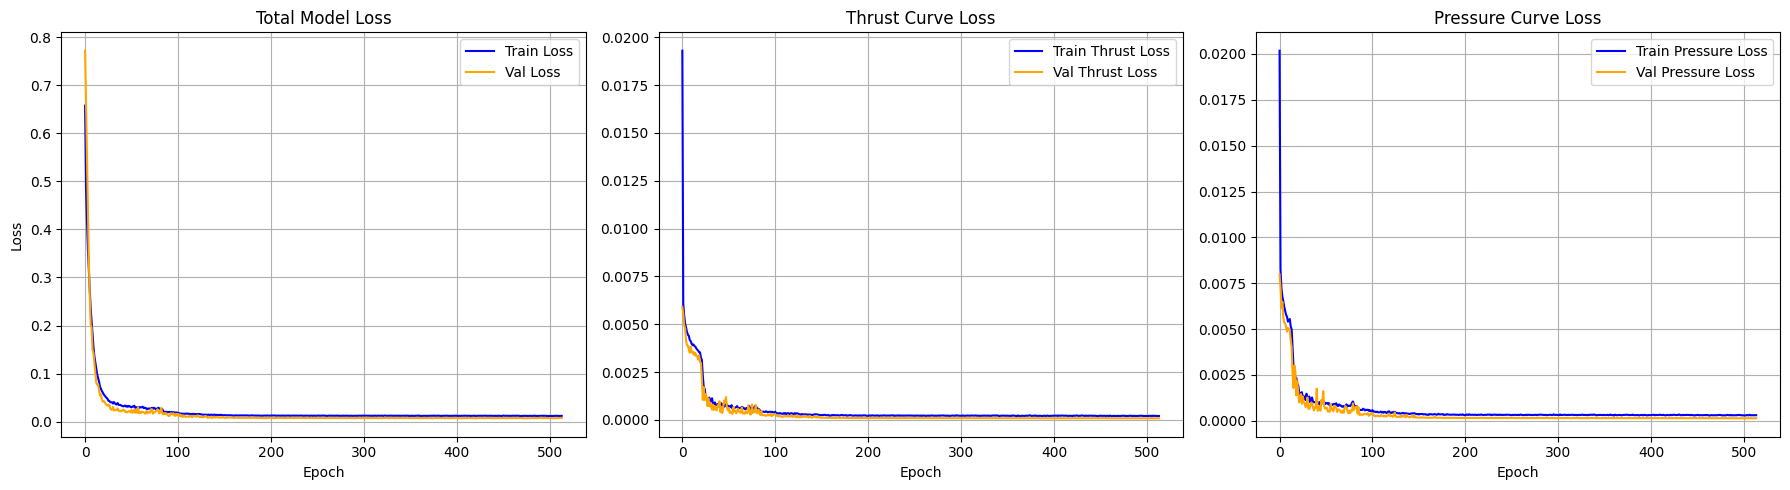

In [29]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Total Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(history.history['thrust_output_loss'], label='Train Thrust Loss', color='blue')
plt.plot(history.history['val_thrust_output_loss'], label='Val Thrust Loss', color='orange')
plt.title('Thrust Curve Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(history.history['pressure_output_loss'], label='Train Pressure Loss', color='blue')
plt.plot(history.history['val_pressure_output_loss'], label='Val Pressure Loss', color='orange')
plt.title('Pressure Curve Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

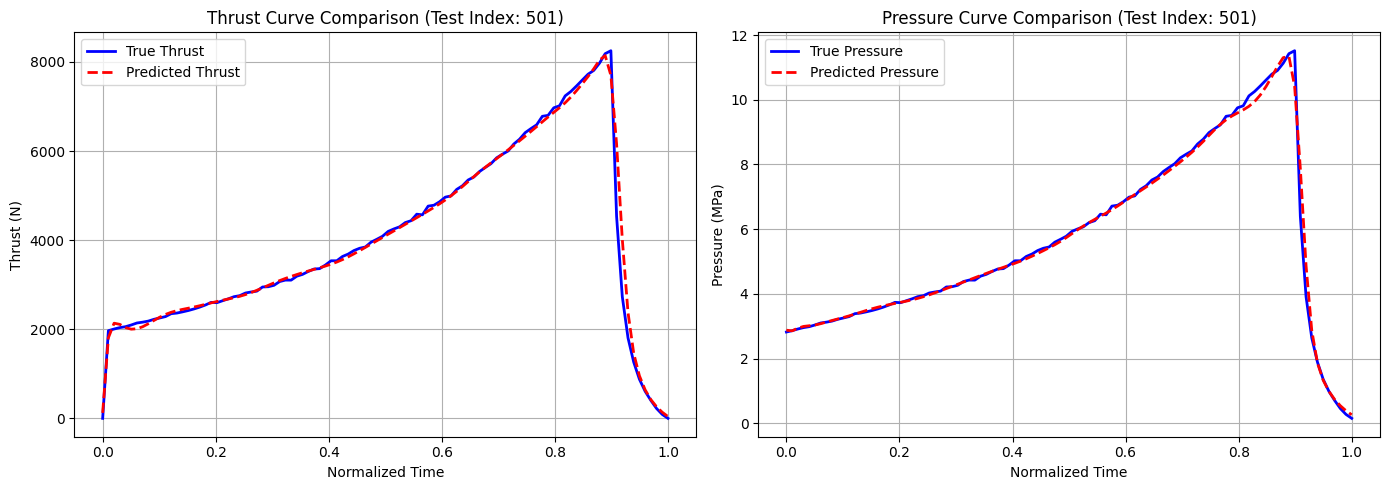


--- Scalar Predictions for Test Index 501 ---
ISP:
  True Value: 174.4600
  Predicted:  174.8248
  Error:      0.21%

Total_Impulse:
  True Value: 29583.1382
  Predicted:  29582.3516
  Error:      0.00%

Burn_Time:
  True Value: 7.4200
  Predicted:  7.3519
  Error:      0.92%

Max_Thrust:
  True Value: 8263.6357
  Predicted:  8262.3955
  Error:      0.02%

Peak Pressure (MPa):
  True Value: 11.5324
  Predicted:  11.5497
  Error:      0.15%



In [46]:
def evaluate_test_sample(index):
    if index >= len(X_te_s):
        print(f"Error: Index out of bounds. Max index available is {len(X_te_s)-1}")
        return

    # 1. Extract the specific sample from the test set
    x_sample = X_te_s[index:index+1]
    true_thrust_scaled = yt_te_s[index]
    true_pressure_scaled = yp_te_s[index]
    true_scalars_scaled = ys_te_s[index:index+1]

    # 2. Make predictions using the model
    pred_thrust_scaled, pred_pressure_scaled, pred_scalars_scaled = model.predict(x_sample, verbose=0)

    # 3. Unscale (Inverse Transform) to bring values back to original physical units
    true_thrust = true_thrust_scaled * max_thrust_global
    pred_thrust = pred_thrust_scaled[0] * max_thrust_global

    true_pressure = true_pressure_scaled * max_pressure_global
    pred_pressure = pred_pressure_scaled[0] * max_pressure_global

    true_scalars = scaler_ys.inverse_transform(true_scalars_scaled)[0]
    pred_scalars = scaler_ys.inverse_transform(pred_scalars_scaled)[0]

    # 4. Plot Curves (True vs Predicted)
    time_axis = np.linspace(0, 1, CURVE_POINTS)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Thrust Plot
    ax1.plot(time_axis, true_thrust, 'b-', label='True Thrust', linewidth=2)
    ax1.plot(time_axis, pred_thrust, 'r--', label='Predicted Thrust', linewidth=2)
    ax1.set_title(f"Thrust Curve Comparison (Test Index: {index})")
    ax1.set_xlabel("Normalized Time")
    ax1.set_ylabel("Thrust (N)")
    ax1.legend()
    ax1.grid(True)

    # Pressure Plot
    ax2.plot(time_axis, true_pressure, 'b-', label='True Pressure', linewidth=2)
    ax2.plot(time_axis, pred_pressure, 'r--', label='Predicted Pressure', linewidth=2)
    ax2.set_title(f"Pressure Curve Comparison (Test Index: {index})")
    ax2.set_xlabel("Normalized Time")
    ax2.set_ylabel("Pressure (MPa)")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    # 5. Print Scalar Results and Error Percentage
    scalar_names = ['ISP', 'Total_Impulse', 'Burn_Time', 'Max_Thrust', 'Peak Pressure (MPa)']
    print(f"\n--- Scalar Predictions for Test Index {index} ---")
    for i, name in enumerate(scalar_names):
        true_val = true_scalars[i]
        pred_val = pred_scalars[i]
        error = abs(true_val - pred_val) / (abs(true_val) + 1e-9) * 100
        
        print(f"{name}:")
        print(f"  True Value: {true_val:.4f}")
        print(f"  Predicted:  {pred_val:.4f}")
        print(f"  Error:      {error:.2f}%\n")

# --- Change this index to test different cases from your test set ---
TEST_INDEX = 501 
evaluate_test_sample(TEST_INDEX)

In [32]:
print("=== Global Evaluation on Entire Test Data ===")

all_preds = model.predict(X_te_s, verbose=0)
all_pred_scalars = scaler_ys.inverse_transform(all_preds[2])

labels = ['ISP (s)', 'Total Impulse (Ns)', 'Burn Time (s)', 'Max Thrust (N)', 'Peak Pressure (MPa)']

for i, label in enumerate(labels):
    actual = ys_test[:, i]
    predicted = all_pred_scalars[:, i]
    mape = np.mean(np.abs((actual - predicted) / (actual + 1e-9))) * 100
    print(f"Mean MAPE for {label:<25}: {mape:.2f}%")

print("\nIf all MAPE values are below 5%, the model is highly accurate!")

=== Global Evaluation on Entire Test Data ===
Mean MAPE for ISP (s)                  : 0.17%
Mean MAPE for Total Impulse (Ns)       : 3.14%
Mean MAPE for Burn Time (s)            : 0.92%
Mean MAPE for Max Thrust (N)           : 2.67%
Mean MAPE for Peak Pressure (MPa)      : 2.45%

If all MAPE values are below 5%, the model is highly accurate!


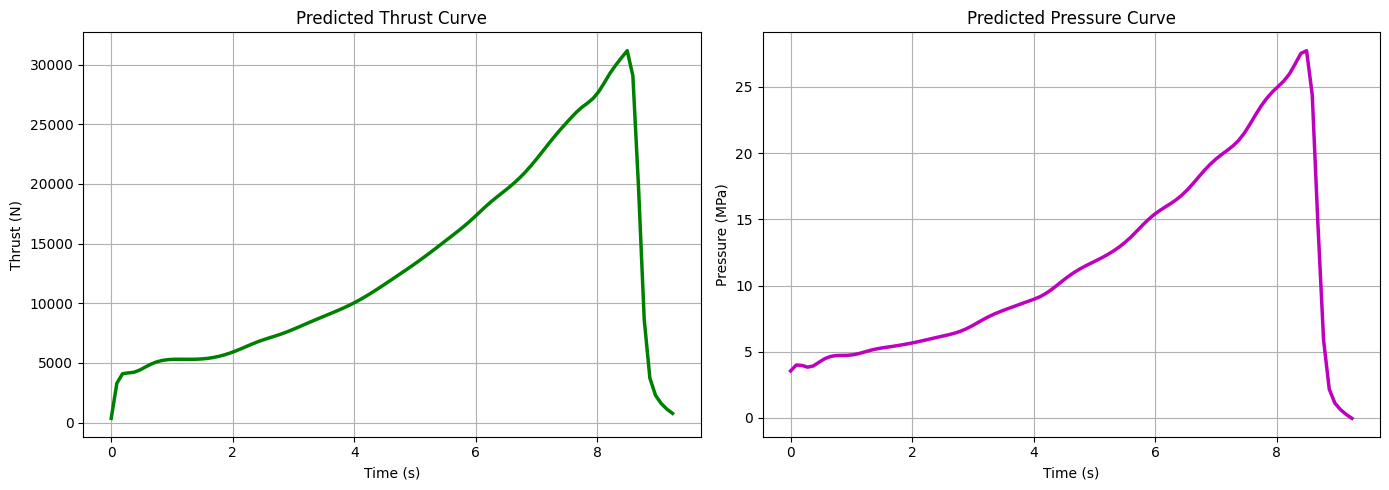


--- Predicted Performance Metrics ---
ISP (s)                  : 176.7482
Total Impulse (Ns)       : 122339.5078
Burn Time (s)            : 9.2389
Max Thrust (N)           : 33753.4766
Peak Pressure (MPa)      : 29.1791


In [33]:
# Updated to match the exact order: Length, Diameter, Slot_Length, Slot_Width, Throat_Diameter, Exit_Diameter
def predict_custom_geometry(length, diameter, slot_length, slot_width, throat_diameter, exit_diameter):
    custom_input = np.array([[length, diameter, slot_length, slot_width, throat_diameter, exit_diameter]])
    custom_input_scaled = scaler_X.transform(custom_input)

    pred_thrust_scaled, pred_pressure_scaled, pred_scalars_scaled = model.predict(custom_input_scaled, verbose=0)

    # إرجاع القيم لأصلها
    pred_thrust = pred_thrust_scaled[0] * max_thrust_global
    pred_pressure = pred_pressure_scaled[0] * max_pressure_global
    pred_scalars = scaler_ys.inverse_transform(pred_scalars_scaled)[0]


    burn_time_val = pred_scalars[2]

    # -----------------------------------------------------------------
    time_axis = np.linspace(0, burn_time_val, CURVE_POINTS)
    # -----------------------------------------------------------------

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(time_axis, pred_thrust, 'g-', linewidth=2.5)
    ax1.set_title("Predicted Thrust Curve")
    ax1.set_xlabel("Time (s)") 
    ax1.set_ylabel("Thrust (N)")
    ax1.grid(True)

    ax2.plot(time_axis, pred_pressure, 'm-', linewidth=2.5)
    ax2.set_title("Predicted Pressure Curve")
    ax2.set_xlabel("Time (s)")
    ax2.set_ylabel("Pressure (MPa)")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    scalar_names = ['ISP (s)', 'Total Impulse (Ns)', 'Burn Time (s)', 'Max Thrust (N)', 'Peak Pressure (MPa)']
    print("\n--- Predicted Performance Metrics ---")
    for i, name in enumerate(scalar_names):
        print(f"{name:<25}: {pred_scalars[i]:.4f}")

# =====================================================================
# ENTER YOUR CUSTOM DIMENSIONS HERE:
# =====================================================================
L  = 130     # Length
D  = 20	      # Diameter
SL = 2.5      # Slot_Length
SW = 2.4     # Slot_Width
TD = 3.3     # Throat_Diameter
ED = 4.95     # Exit_Diameter

predict_custom_geometry(L, D, SL, SW, TD, ED)

In [34]:
import pickle
import os
import tensorflow as tf

# Create the save directory if it doesn't exist
save_dir = 'rocket_model_v1'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 1. Save the model using the modern .keras format
model_path = os.path.join(save_dir, 'rocket_motor_model.keras')
model.save(model_path)
print(f"[1] Model saved successfully at: {model_path}")

# 2. Plot and save the model architecture as an image (Great for graduation project docs)
try:
    plot_path = os.path.join(save_dir, 'model_architecture.png')
    tf.keras.utils.plot_model(model, to_file=plot_path, show_shapes=True, show_layer_names=True)
    print(f"[2] Model architecture image saved at: {plot_path}")
except Exception as e:
    print(f"[2] Could not save architecture image. (Ensure 'pydot' and 'graphviz' are installed). Error: {e}")

# 3. Prepare the comprehensive data dictionary for saving
scalers_data = {
    'scaler_X': scaler_X,
    'scaler_ys': scaler_ys,
    'max_thrust_global': max_thrust_global,
    'max_pressure_global': max_pressure_global,
    'curve_points': CURVE_POINTS
}

# Add training history if it exists in memory
if 'history' in locals() or 'history' in globals():
    scalers_data['training_history'] = history.history
    print("[3] Training history added to the save file.")
else:
    print("[3] No training history found in memory to save. (Make sure you used history = model.fit(...))")

# 4. Save scalers, constants, and training history in a Pickle file
scalers_path = os.path.join(save_dir, 'scalers_and_constants.pkl')
with open(scalers_path, 'wb') as f:
    pickle.dump(scalers_data, f)

print(f"[4] Scalers, constants, and history saved successfully at: {scalers_path}")
print("="*60)
print("All project files are fully secured and ready for presentation!")

Model saved successfully at: rocket_model_v1/rocket_motor_model.h5
Scalers and constants saved successfully at: rocket_model_v1/scalers_and_constants.pkl


In [35]:
import os
for dirname, _, filenames in os.walk('/kaggle/working/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/working/.virtual_documents/__notebook_source__.ipynb
/kaggle/working/rocket_model_v1/rocket_motor_model.h5
/kaggle/working/rocket_model_v1/scalers_and_constants.pkl


In [36]:
import tensorflow as tf
import pickle
import os

# 1. Define the Custom Loss Function (Crucial for loading the model)
def shape_matching_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    # Standard Mean Squared Error
    mse = tf.reduce_mean(tf.square(y_true - y_pred), axis=-1)
    
    # Shape penalty (differences between consecutive points)
    diff_true = y_true[:, 1:] - y_true[:, :-1]
    diff_pred = y_pred[:, 1:] - y_pred[:, :-1]
    shape_penalty = tf.reduce_mean(tf.square(diff_true - diff_pred), axis=-1)
    
    return mse + 0.5 * shape_penalty

# 2. Paths to the saved files
save_dir = 'rocket_model_v1'
model_path = os.path.join(save_dir, 'rocket_motor_model.keras')
scalers_path = os.path.join(save_dir, 'scalers_and_constants.pkl')

# 3. Load the Keras model
if os.path.exists(model_path):
    loaded_model = tf.keras.models.load_model(
        model_path, 
        custom_objects={'shape_matching_loss': shape_matching_loss}
    )
    print("[1] Model loaded successfully.")
else:
    print(f"Error: Model file not found at {model_path}")

# 4. Load scalers, constants, and training history
if os.path.exists(scalers_path):
    with open(scalers_path, 'rb') as f:
        loaded_data = pickle.load(f)
    
    # Extracting variables
    l_scaler_X = loaded_data['scaler_X']
    l_scaler_ys = loaded_data['scaler_ys']
    l_max_thrust = loaded_data['max_thrust_global']
    l_max_pressure = loaded_data['max_pressure_global']
    l_curve_points = loaded_data['curve_points']
    
    # Check if history exists
    if 'training_history' in loaded_data:
        l_history = loaded_data['training_history']
        print("[2] Scalers and Training History loaded successfully.")
    else:
        print("[2] Scalers loaded successfully (No history found).")
else:
    print(f"Error: Scalers file not found at {scalers_path}")

print("="*60)
print("System ready for performance prediction!")

Model and Scalers loaded successfully! You are ready for inference.


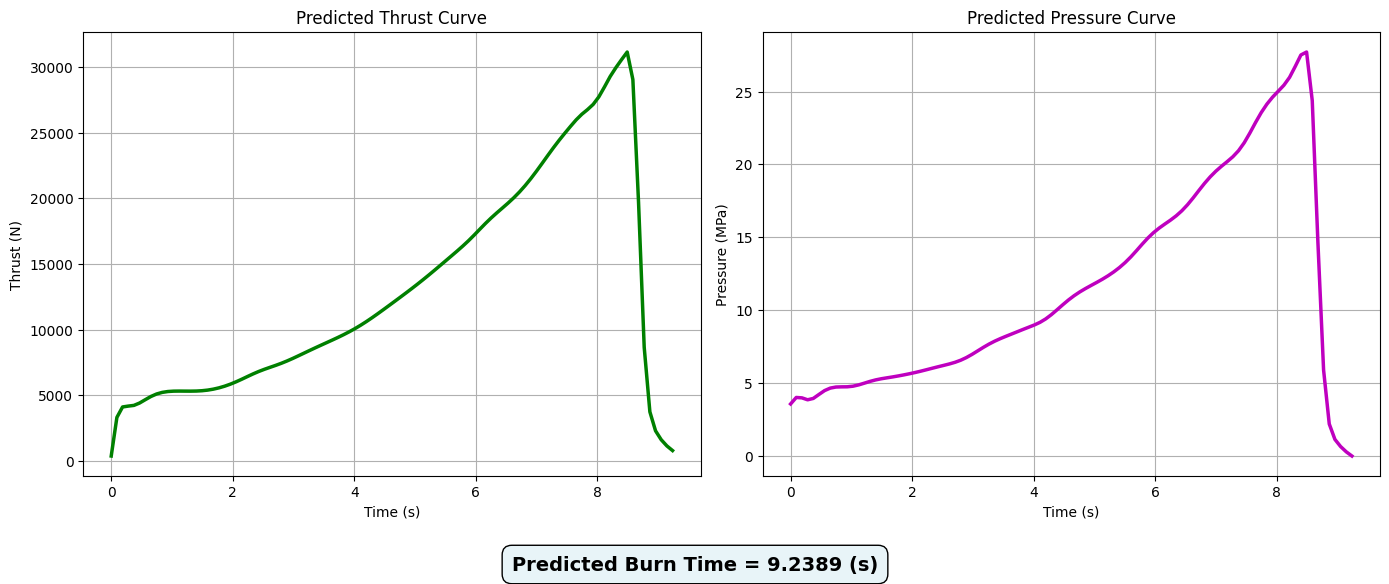


--- Predicted Performance Metrics ---
ISP (s)                  : 176.7482
Total Impulse (Ns)       : 122339.5078
Burn Time (s)            : 9.2389
Max Thrust (N)           : 33753.4766
Peak Pressure (MPa)      : 29.1791


In [39]:
import numpy as np
import matplotlib.pyplot as plt

def predict_custom_geometry(length, diameter, slot_length, slot_width, throat_diameter, exit_diameter):
    # 1. Prepare inputs in the exact order the model was trained on
    custom_input = np.array([[length, diameter, slot_length, slot_width, throat_diameter, exit_diameter]])
    
    # 2. Scale the new inputs using the fitted RobustScaler
    custom_input_scaled = scaler_X.transform(custom_input)

    # 3. Predict using the trained model
    pred_thrust_scaled, pred_pressure_scaled, pred_scalars_scaled = model.predict(custom_input_scaled, verbose=0)

    # 4. Inverse transform to get true physical units (N and MPa)
    pred_thrust = pred_thrust_scaled[0] * max_thrust_global
    pred_pressure = pred_pressure_scaled[0] * max_pressure_global
    pred_scalars = scaler_ys.inverse_transform(pred_scalars_scaled)[0]

    # 5. Extract predicted Burn Time to adjust the Time axis
    burn_time_val = pred_scalars[2]

    # Create the true time axis in seconds (from 0 to Burn Time)
    time_axis = np.linspace(0, burn_time_val, CURVE_POINTS)

    # 6. Plot the curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Plot Thrust Curve
    ax1.plot(time_axis, pred_thrust, 'g-', linewidth=2.5)
    ax1.set_title("Predicted Thrust Curve")
    ax1.set_xlabel("Time (s)") 
    ax1.set_ylabel("Thrust (N)")
    ax1.grid(True)

    # Plot Pressure Curve
    ax2.plot(time_axis, pred_pressure, 'm-', linewidth=2.5)
    ax2.set_title("Predicted Pressure Curve")
    ax2.set_xlabel("Time (s)")
    ax2.set_ylabel("Pressure (MPa)")
    ax2.grid(True)

    # Adjust layout to leave 10% empty space at the bottom
    plt.tight_layout(rect=[0, 0.1, 1, 1])

    # Add a text box displaying the Burn Time at the bottom center
    fig.text(0.5, 0.05, f"Predicted Burn Time = {burn_time_val:.4f} (s)", 
             ha='center', va='center', fontsize=14, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.5", facecolor="#e8f4f8", edgecolor="black"))

    plt.show()

    # 7. Print all static performance metrics
    scalar_names = ['ISP (s)', 'Total Impulse (Ns)', 'Burn Time (s)', 'Max Thrust (N)', 'Peak Pressure (MPa)']
    print("\n--- Predicted Performance Metrics ---")
    for i, name in enumerate(scalar_names):
        print(f"{name:<25}: {pred_scalars[i]:.4f}")

# =====================================================================
# ENTER NEW MOTOR DESIGN DIMENSIONS HERE:
# =====================================================================
L  = 130     # Length
D  = 20	      # Diameter
SL = 2.5      # Slot_Length
SW = 2.4     # Slot_Width
TD = 3.3     # Throat_Diameter
ED = 4.95     # Exit_Diameter

predict_custom_geometry(L, D, SL, SW, TD, ED)


In [41]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# 1. Read the dataset containing the 6 scaled cases and their actual results
file_eval = '/kaggle/input/datasets/abdelrahmanmr/test-model/as__Summary_Results.xlsx' 

# Smart fallback: Try reading as CSV first, if it fails because it's an actual Excel file, use read_excel
try:
    df_eval = pd.read_csv(file_eval)
except:
    df_eval = pd.read_excel(file_eval)

# 2. Extract the inputs (the 6 geometric dimensions)
input_cols = ['Length', 'Diameter', 'Slot_Length', 'Slot_Width', 'Throat_Diameter', 'Exit_Diameter']
X_extrap = df_eval[input_cols].values

# 3. Extract the actual results (Ground Truth) in the exact order the model expects
target_cols = ['ISP (s)', 'Total Impulse (Ns)', 'Burn Time (s)', 'Max Thrust (N)', 'Peak Pressure (MPa)']
ys_true_extrap = df_eval[target_cols].values

# 4. Scale inputs and predict using the LOADED model and scalers
# --> Changed variables to l_scaler_X and loaded_model
X_extrap_scaled = l_scaler_X.transform(X_extrap)
_, _, p_scalars_scaled = loaded_model.predict(X_extrap_scaled, verbose=0)

# Inverse transform to get physical units back
# --> Changed variable to l_scaler_ys
ys_pred_extrap = l_scaler_ys.inverse_transform(p_scalars_scaled)

# 5. Define case names (first 3 are scaled down, last 3 are scaled up)
case_names = [
    "Scaling -25% (Below Range)",
    "Scaling -30% (Below Range)",
    "Scaling -35% (Below Range)",
    "Scaling +35% (Above Range)",
    "Scaling +30% (Above Range)",
    "Scaling +25% (Above Range)"
]

# 6. Build a comprehensive comparison list
results_list = []

for i, case in enumerate(case_names):
    for j, metric in enumerate(target_cols):
        true_val = ys_true_extrap[i][j]
        pred_val = ys_pred_extrap[i][j]
        
        # Calculate Mean Absolute Percentage Error (MAPE)
        error = np.abs((true_val - pred_val) / (true_val + 1e-9)) * 100
        
        # Determine the range category based on the case name
        range_type = "Below Range" if "Below" in case else "Above Range"
        
        results_list.append({
            "Range": range_type,
            "Case": case.split(" ")[1], # Extract only the percentage (e.g., -25%)
            "Metric": metric,
            "Actual Data": true_val,
            "Model Prediction": pred_val,
            "Error (%)": error
        })

# Convert the list to a pandas DataFrame for a professional look
results_df = pd.DataFrame(results_list)

# 7. Display the detailed sheet for each individual case
print("=" * 80)
print(f"{'DETAILED EXTRAPOLATION SHEET':^80}")
print("=" * 80)
# Format numbers for better readability
pd.options.display.float_format = '{:.4f}'.format
display(results_df)

# 8. Display the summary of average errors per range
print("\n" + "=" * 80)
print(f"{'AVERAGE ERROR BY RANGE (MODEL ROBUSTNESS)':^80}")
print("=" * 80)

# Aggregate data to calculate the mean error for each metric within each range
summary_df = results_df.groupby(['Range', 'Metric'])['Error (%)'].mean().unstack()

# Add a column for the overall average error across all metrics in that range
summary_df['Overall Range Error'] = summary_df.mean(axis=1)

display(summary_df)

                          DETAILED EXTRAPOLATION SHEET                          


,Range,Case,Metric,Actual Data,Model Prediction,Error (%)
0,Below Range,-25%,ISP (s),148.7360,148.7752,0.0264
1,Below Range,-25%,Total Impulse (Ns),1318.9838,-1087.4915,182.4492
2,Below Range,-25%,Burn Time (s),5.1550,5.0718,1.6146
3,Below Range,-25%,Max Thrust (N),619.6430,259.1437,58.1786
4,Below Range,-25%,Peak Pressure (MPa),2.4894,3.6392,46.1860
5,Below Range,-30%,ISP (s),147.8907,148.3434,0.3061
6,Below Range,-30%,Total Impulse (Ns),963.1651,-2338.5129,342.7946
7,Below Range,-30%,Burn Time (s),4.3600,4.1712,4.3300
8,Below Range,-30%,Max Thrust (N),530.3700,51.5577,90.2789
9,Below Range,-30%,Peak Pressure (MPa),2.4508,3.8644,57.6792



                   AVERAGE ERROR BY RANGE (MODEL ROBUSTNESS)                    


Metric,Burn Time (s),ISP (s),Max Thrust (N),Peak Pressure (MPa),Total Impulse (Ns),Overall Range Error
Range,,,,,,
Above Range,2.4751,1.0070,9.8029,37.2921,19.4908,14.0136
Below Range,2.5055,0.1863,103.6333,57.6040,386.7236,110.1306
